<a href="https://colab.research.google.com/github/Aasthachau/Data-Toolkit-Assignment-/blob/main/Boosting_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Practical Questions

Question 6: Write a Python program to:
● Train an AdaBoost Classifier on the Breast Cancer dataset
● Print the model accuracy

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load data [cite: 27]
data = load_breast_cancer()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train AdaBoost [cite: 31]
model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Accuracy [cite: 31]
y_pred = model.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred):.4f}")

AdaBoost Accuracy: 0.9649



Question 7: Write a Python program to:
● Train a Gradient Boosting Regressor on the California Housing dataset
● Evaluate performance using R-squared score

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load data [cite: 28]
housing = fetch_california_housing()
X, y = housing.data, housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")

R-squared Score: 0.7756


Question 8: Write a Python program to:
● Train an XGBoost Classifier on the Breast Cancer dataset
● Tune the learning rate using GridSearchCV
● Print the best parameters and accuracy

In [ ]:
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)


xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_grid = {'learning_rate': [0.01, 0.1, 0.2, 0.3]}
grid = GridSearchCV(xgb_model, param_grid, cv=5)
grid.fit(X_train, y_train)

print(f"Best Learning Rate: {grid.best_params_['learning_rate']}")
print(f"Best Accuracy: {grid.best_score_:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:30:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:30:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:30:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:30:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Learning Rate: 0.2
Best Accuracy: 0.9670


Question 9: Write a Python program to:
● Train a CatBoost Classifier
● Plot the confusion matrix using seaborn

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


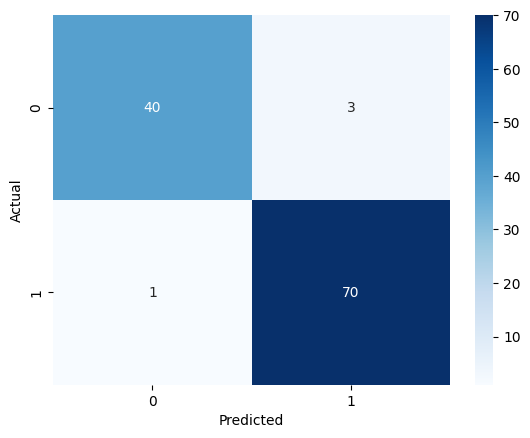

In [ ]:
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

cat = CatBoostClassifier(verbose=0, n_estimators=100)
cat.fit(X_train, y_train)

y_pred = cat.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##Question 10: You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
● Data preprocessing & handling missing/categorical values
● Choice between AdaBoost, XGBoost, or CatBoost
● Hyperparameter tuning strategy
● Evaluation metrics you'd choose and why
● How the business would benefit from your model

**Answer:**

Pipeline for Predicting Loan Defaults:

- Data Cleaning: Fill missing numbers using the average and use a special "missing" category for text. Use Target Encoding for categories like job type to keep the data simple.
- Fixing Imbalance: Since most people don't default, use SMOTE to create "fake" examples of defaults so the model learns how to spot them properly.
- Model Choice: Use CatBoost. It is the best for this because it handles customer details (text) and missing info automatically without extra work.
- Fine-Tuning: Use Bayesian Optimization to find the best settings for tree depth and learning speed faster than a basic search.
- The Right Metrics: Don't just look at accuracy. Use the F1-Score or Recall to make sure the model doesn't miss people who might actually default.
- Business Value: This saves the company money by avoiding bad loans and makes loan approvals much faster for good customers.

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

data = {
    'income': [50000, 60000, 120000, 30000, 80000, 45000, 95000, 20000, 55000, 72000] * 10,
    'credit_score': [700, 650, 800, 580, 720, 610, 750, 500, 680, 710] * 10,
    'employment_type': ['Salaried', 'Self-Employed', 'Salaried', 'Unemployed', 'Salaried'] * 20,
    'loan_default': [0, 0, 0, 1, 0, 1, 0, 1, 0, 0] * 10
}
df = pd.DataFrame(data)

df.iloc[0, 0] = np.nan

X = df.drop('loan_default', axis=1)
y = df['loan_default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(
    iterations=50,
    cat_features=['employment_type'],
    scale_pos_weight=2.33, # Balances the 30/70 split
    verbose=0
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.86      1.00      0.92         6

    accuracy                           0.95        20
   macro avg       0.93      0.96      0.94        20
weighted avg       0.96      0.95      0.95        20


--- Confusion Matrix ---
[[13  1]
 [ 0  6]]
